# Travaux pratiques, semaine 10. 
## Introduction aux méthodes itératives.

In [20]:
# Chargement des bibliothèques
import numpy as np                # Pour faire du calcul scientifique
import matplotlib.pyplot as plt   # Pour illustrer les résultats à l’aide de graphiques

## Exercice 1 (exemple de factorisation LU de matrice creuse)


**1.** On considère, pour un paramètre $α$ donné, la matrice carrée de taille $n$ suivante :

$$A=\begin{pmatrix}
1      & α  & \cdots & \cdots & α\\
α      & 1   & 0    & \cdots & 0\\
\vdots & 0   & \ddots & \ddots & \vdots \\
\vdots & \vdots & \ddots & 1 & 0 \\
α      &  0 & \cdots & 0  & 1
\end{pmatrix}.$$

Fixer $n=5$ et $α=-0.1$, construire la matrice $A$, calculer sa décomposition LU (on pourra réutiliser du code des TP précédents), et sa factorisation de Cholesky (avec `np.linalg.cholesky`). Qu’observe-t-on ?

In [21]:
def LU(A):
    n = len(A)
    B = A.copy()
    for k in range(n-1):
        B[k+1:,k] = B[k+1:,k]/B[k,k]
        B[k+1:,k+1:] = B[k+1:,k+1:] - B[k+1:,k:k+1].dot(B[k:k+1,k+1:])
    return B

In [22]:
n = 5 
alpha = -0.1
A = np.eye(n)
A[1:,0] = alpha
A[0,1:] = alpha
L_chol = np.linalg.cholesky(A)
B = LU(A)
L_LU = np.tril(B,k=-1) + np.eye(n)
U_LU = np.triu(B) 
print("L de Cholesky -------------------------------------")
print(L_chol)
print("L de LU -------------------------------------")
print(L_LU)


L de Cholesky -------------------------------------
[[ 1.          0.          0.          0.          0.        ]
 [-0.1         0.99498744  0.          0.          0.        ]
 [-0.1        -0.01005038  0.99493668  0.          0.        ]
 [-0.1        -0.01005038 -0.01015242  0.99488488  0.        ]
 [-0.1        -0.01005038 -0.01015242 -0.01025655  0.99483201]]
L de LU -------------------------------------
[[ 1.          0.          0.          0.          0.        ]
 [-0.1         1.          0.          0.          0.        ]
 [-0.1        -0.01010101  1.          0.          0.        ]
 [-0.1        -0.01010101 -0.01020408  1.          0.        ]
 [-0.1        -0.01010101 -0.01020408 -0.01030928  1.        ]]


**Remarque:** Beaucoup de coefficients non nuls dans ces décompositions, en dépit d'une matrice de départ qui était creuse ...

**2.** Pour résoudre un système $Ax=b$, pourquoi n’est-il pas raisonnable de stocker la matrice $A$ directement, et de faire sa décomposition $LU$ (ou Cholesky ici), lorsque $n=10^4$ par exemple ? Écrire une fonction `multA` prenant en entrée un vecteur $x$ (codé par un tableau unidimensionnel) et renvoyant $Ax$, sans stocker de matrice (on pourra vérifier pour des petites valeurs de $n$ que cela donne bien le bon résultat).

Pour des matrices très larges avec une structure simple à décrire et assez sparse, il est contreproductif de chercher à les stocker dans un immense array. La décomposition LU ou de Cholesky étant  d'une complexité $O(n^3) = 10^{12}$ opérations élémentaires : bien trop coûteux ! Il faut se servir de sa structure.

In [23]:
def multA(x,alpha = -0.1):
    n = x.shape[0]
    y = x.copy()
    y[0] += alpha*np.sum(x[1:])
    y[1:]+= alpha*x[0]
    return y

x = np.ones(5)
print(multA(x))

[0.6 0.9 0.9 0.9 0.9]


**3.** Plutôt que de calculer la solution de $Ax=b$ par une méthode directe (qui prendrait trop de place en mémoire), on veut utiliser le fait que le calcul de $Ax$ est facile à effectuer. On utilise une méthode de point fixe en posant $x_0∈ℝ^n$ et 
$$ x_{k+1}=g(x_k)=x_k + (b-Ax_k).$$

Écrire une fonction `methodeIterativeA` prenant en entrée le vecteur $b$, l’initialisation $x_0$  (sous forme de tableaux unidimensionnels), un nombre $k_{\max}$, et renvoyant une liste de tous les $x_k$ pour $0⩽k⩽k_{\max}$.

Générer un vecteur $b=Ax_*$ en prenant un vecteur $x_*$ arbitraire, puis tracer les normes $\|x_k-x_*\|$ pour $0⩽k⩽k_{\max}$, où les $x_k$ sont obtenus par la méthode avec $x_0$ arbitraire (on pourra tirer un vecteur aléatoirement, ou simplement prendre $x_0=0$). À quelle vitesse la suite converge-t-elle ?

taux de convergence = 0.20


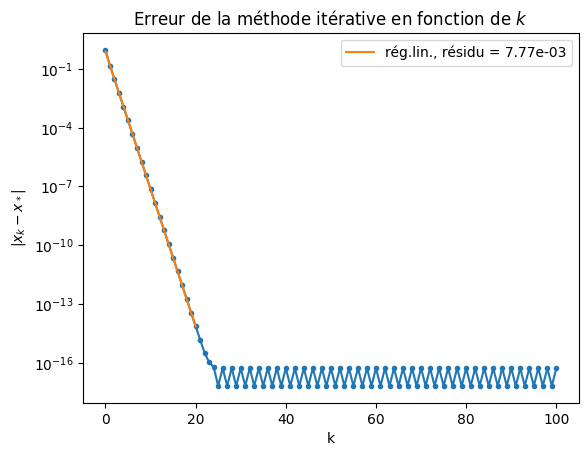

In [24]:
np.random.seed(1)
def methodeIterativeA(b,x0,kmax,alpha = -0.1):
    n = b.shape[0]
    vx = np.zeros((n,kmax+1))
    vx[:,0] = x0.copy()
    for k in range(1,kmax+1):
        vx[:,k] = vx[:,k-1] + b - multA(vx[:,k-1],alpha = alpha)
    return vx


n = 5
xstar = np.random.rand(n)
b = multA(xstar)
kmax = 100
vx = methodeIterativeA(b,x0=np.zeros(n),kmax=kmax)
vx = vx - np.outer(xstar,np.ones(kmax+1))
verr = np.linalg.norm(vx,axis = 0, keepdims = True)[0]
vk = np.arange(kmax+1)
plt.semilogy(vk,verr,".-")
plt.xlabel("k")
plt.ylabel( f"$|x_k-x_*|$")
plt.title(f"Erreur de la méthode itérative en fonction de $k$")

crop = 21
coeffs, r, _,_,_ = np.polyfit(vk[:crop],np.log10(verr[:crop]),deg = 1,full = True)
coeff, oorigine = coeffs[0], coeffs[1]
r = r[0]
plt.semilogy(vk[:crop],10**(coeff*vk[:crop]+oorigine), label = f"rég.lin., résidu = {r:.2e}")
plt.legend()
tc = 10**coeff
print(f"taux de convergence = {tc:.2f}")


La suite des erreurs converge linéairement vers $0$ au taux de convergence

**4.** Que se passe-t-il pour des $n$ plus grands ? Tester par exemple avec $n=20$, puis $n=200$, toujours pour $α=-0.1$. 

On copie-colle le scripte précédent en changeant simplement l'affectation à `n`. Pour $n = 20$, on a toujours de la convergence à mais à pire taux ($0.44$). Pour $n = 200$, on a de la divergence (à taux $1.41$)

taux de convergence = 0.44


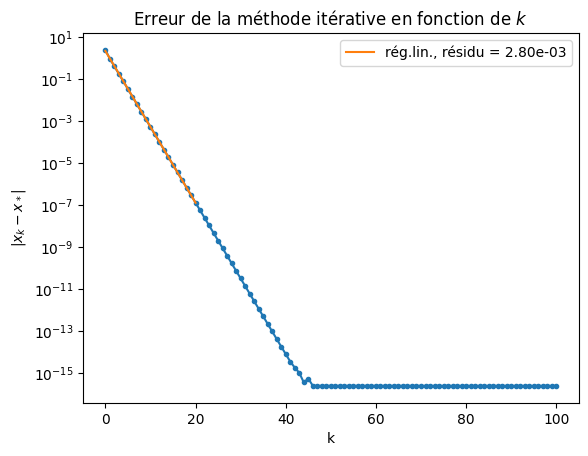

In [25]:
n = 20
xstar = np.random.rand(n)
b = multA(xstar)
kmax = 100
vx = methodeIterativeA(b,x0=np.zeros(n),kmax=kmax)
vx = vx - np.outer(xstar,np.ones(kmax+1))
verr = np.linalg.norm(vx,axis = 0, keepdims = True)[0]
vk = np.arange(kmax+1)
plt.semilogy(vk,verr,".-")
plt.xlabel("k")
plt.ylabel( f"$|x_k-x_*|$")
plt.title(f"Erreur de la méthode itérative en fonction de $k$")

crop = 21
coeffs, r, _,_,_ = np.polyfit(vk[:crop],np.log10(verr[:crop]),deg = 1,full = True)
coeff, oorigine = coeffs[0], coeffs[1]
r = r[0]
plt.semilogy(vk[:crop],10**(coeff*vk[:crop]+oorigine), label = f"rég.lin., résidu = {r:.2e}")
plt.legend()
tc = 10**coeff
print(f"taux de convergence = {tc:.2f}")

taux de divergence = 1.41


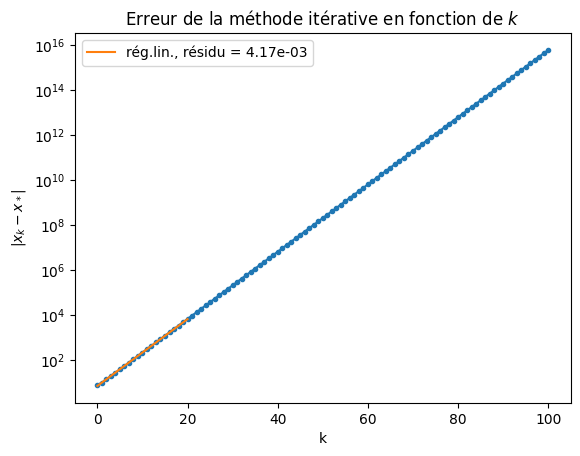

In [26]:
n = 200
xstar = np.random.rand(n)
b = multA(xstar)
kmax = 100
vx = methodeIterativeA(b,x0=np.zeros(n),kmax=kmax)
vx = vx - np.outer(xstar,np.ones(kmax+1))
verr = np.linalg.norm(vx,axis = 0, keepdims = True)[0]
vk = np.arange(kmax+1)
plt.semilogy(vk,verr,".-")
plt.xlabel("k")
plt.ylabel( f"$|x_k-x_*|$")
plt.title(f"Erreur de la méthode itérative en fonction de $k$")

crop = 21
coeffs, r, _,_,_ = np.polyfit(vk[:crop],np.log10(verr[:crop]),deg = 1,full = True)
coeff, oorigine = coeffs[0], coeffs[1]
r = r[0]
plt.semilogy(vk[:crop],10**(coeff*vk[:crop]+oorigine), label = f"rég.lin., résidu = {r:.2e}")
plt.legend()
tc = 10**coeff
print(f"taux de divergence = {tc:.2f}")

**5.** Pour $n=2000$ et $α=0.01$, à l’aide de la commande %time, comparer le temps de calcul de la solution par méthode directe (avec `np.linalg.solve`, pourtant très optimisée), et la méthode itérative (avec suffisamment d’itérations pour obtenir la même précision).

CPU times: user 3.47 ms, sys: 385 μs, total: 3.86 ms
Wall time: 2.99 ms


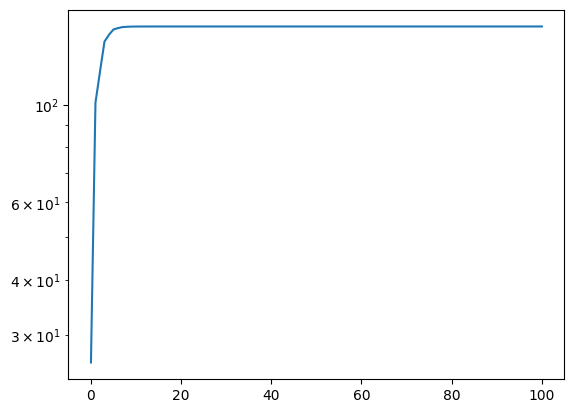

In [58]:
n = 2000
alpha = 0.01
kmax = 100
xstar = np.random.rand(n)
x0  = np.random.rand(n)
x0 = np.zeros(n)
b = multA(xstar)
%time vx = methodeIterativeA(b,x0=x0,kmax=kmax,alpha = alpha)
vx = vx - np.outer(xstar,np.ones(kmax+1))
verr = np.linalg.norm(vx,axis = 0, keepdims = True)[0]

plt.semilogy(verr)

In [59]:
A=np.eye(n)
A[0,1:]=alpha
A[1:,0]=alpha
%time u=np.linalg.solve(A,b)

CPU times: user 1.6 s, sys: 807 ms, total: 2.41 s
Wall time: 350 ms


**Réponse:** Avec ce choix de paramètre, la méthode proposée ne converge pas. Faire 100 itérées est tout de même bien moins long que de faire la décomposition LU de $A$.

## Exercice 2 (Laplacien discret sur le cercle, méthodes de Jacobi et Gauss–Seidel)

On considère la matrice carrée de taille $n$ suivante
$$Δ_n=\begin{pmatrix}
2      & -1  & 0 &  \cdots & 0 & -1\\
-1     & 2   & -1 & \ddots    &  & 0\\
0 & -1   & \ddots & \ddots & \ddots & \vdots \\
\vdots & \ddots  & \ddots & \ddots & \ddots & 0 \\
0 &   & \ddots & \ddots & 2 & -1 \\
-1      &  0 & \cdots & 0  & -1 & 2
\end{pmatrix}.$$
On cherche à résoudre $Ax=b$ avec $A=μI_n+Δ_n$ (et $μ>0$).
On note $E$ la partie triangulaire inférieure stricte de $-A$ (c’est la même que celle de $-Δ_n$, avec seulement des coefficients $1$), $F=E^{\top}$ sa partie triangulaire supérieure stricte, et $D=(μ+2)I_n$ la diagonale de $A$. De sorte que $A=D-(E+F).$ De même que dans la partie précédente, on ne veut pas stocker de telles grandes matrice et leur décompositions (il se trouve que dans ce cas, la décomposition de Cholesky est en fait également creuse, on pourrait seulement stocker les éléments non-nuls), mais plutôt utiliser des méthodes itératives.

**1.** La méthode de Jacobi consiste à poser $x_{k+1}=D^{-1}\big((E+F)x_k+b\big)$. 
Pour $n$ fixé, implémenter cette méthode sous la forme d’une fonction `JacobiA` prenant en argument $b$, $x_0$ et un nombre $k_{max}$ d’itérations, en ne stockant pas les matrices $E$ et $F$ (ni $D$ bien sûr), mais seulement en faisant directement le calcul de $Ex_k$ et $Fx_k$). Tester avec $μ=1$, $n=10$ et $b$ pris de la forme $Ax_*$ (avec $x_*$ aléatoirement choisi), pour pouvoir observer les normes $\|x_k-x_*\|$.

**Réponse :** D'après la théorie, la méthode de Jacobi converge si et seulement si le rayon spectral $\rho(D ^{-1}(E+F))<1$ où $\rho$ désigne le rayon spectral d'une matrice carrée. On peut montrer que $\rho(D ^{-1}(E+F)) = \frac{1}{2+\mu} \rho(E+F) = \frac{2}{2+\mu}.$ 

- En effet $\rho(E+F) \geq 2$ car $(1,\dots,1)$ est un vecteur propre associé à la valeur propre $2$. 
- D'autre part, $\rho(E+F) \leq 2$. En effet, on peut décomposer $E+F$ comme la somme de deux matrices de permutations (donc orthogonales), $E+F = P_\sigma + P_\tau$ où $\tau = (1,2,3,\dots ,n)$ et $\sigma = (n,n-1, \dots, 2,1)$. Ainsi, en norme d'opérateur $\|P_\sigma + P_\tau\| \leq \|P_\sigma\| + \|P_\tau\| \leq 2$ car ce sont des isométries. Donc $\rho(E+F) \leq \|E+F\| = 2$. 

Ici donc, la méthode de Jacobi converge ssi $\mu >0$.



In [60]:
def multAbis(x,mu = 1.):
    n = x.shape[0]
    y = (2+mu)*x.copy()
    y[0] = y[0]-x.copy()[1] - x.copy()[-1]
    y[n-1] = y[n-1]-x.copy()[n-2]-x.copy()[0]
    for k in range(1,n-1):
        y[k] = y[k] -  x.copy()[k-1] - x.copy()[k+1]
    return y

Text(0.5, 1.0, 'Erreur de la méthode itérative en fonction de $k$')

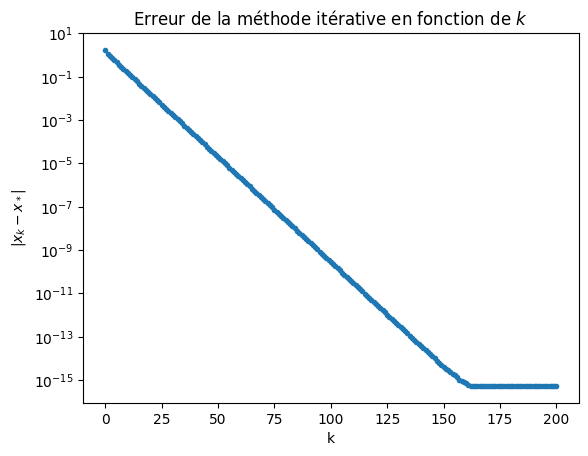

In [62]:
n=10
mu=0.5
kmax = 200
def JacobiA(b,x0=np.zeros(n),kmax=10,mu = 1.):
    xk=np.copy(x0)
    n = len(b)    
    vx = np.zeros((n,kmax+1))
    Exk = np.zeros(n)
    Fxk = np.zeros(n)
    for k in range(1,kmax+1):
        Exk[1:] = xk[:-1]
        Exk[-1] += xk[0]
        Fxk[:-1] = xk[1:]
        Fxk[0] += xk[-1]
        xk = (b + Exk+Fxk)/(2+mu)
        vx[:,k] = xk.copy()
    return vx

xstar = np.random.rand(n)
b = multAbis(xstar,mu = mu)

vx = JacobiA(b,x0=np.zeros(n),kmax = kmax,mu = mu)
sol = vx[:,-1]
vx = vx - np.outer(xstar,np.ones(kmax+1))
verr = np.linalg.norm(vx,axis = 0, keepdims = True)[0]
vk = np.arange(kmax+1)
plt.semilogy(vk,verr,".-")
plt.xlabel("k")
plt.ylabel( f"$|x_k-x_*|$")
plt.title(f"Erreur de la méthode itérative en fonction de $k$")


**2.** La méthode de Gauss–Seidel consiste à poser $x_{k+1}=(D-E)^{-1}(Fx_k+b)$. Coder d’abord une fonction qui calcule directement $(D-E)^{-1}y$ (c’est la solution d’un système triangulaire simple) à partir de $y$, puis implémenter la méthode comme dans la question précédente.

**3.** Que se passe-t-il pour $μ=0$ ? Les méthodes des questions précédentes étant bien définies, observe-t-on une convergence des suites ? Vers quel vecteur ?